### Display clustering results
Notebook to compare two metrics for clustering: MTEB, which uses sklearn.cluster.MiniBatchKMeans() and kNN, which uses sklearn.neighbors.KNeighborsClassifier()
MTEB results are saved in .json files, one for each task. 
kNN results are saved in .json files, one for each model.
This notebook aggregates the results for multiple tasks and multiple models.

In [46]:
import os
import mteb
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
import math
from matplotlib.lines import Line2D

In [2]:
# get task type 
mteb.get_task("ArguAna").metadata.type

'Retrieval'

In [3]:
mteb.get_task("ArguAna").metadata.name

'ArguAna'

#### Analyze MTEB results of different TF-IDF configurations

In [4]:
data = {}
main_dir = "../MTEB/sparse_results/Tfidf"

# Traverse folders and subfolders
for (root, dirs, files) in os.walk(main_dir):
    # Identify model version from the folder structure
    model_version = os.path.basename(root)
    #print(model_version)
        
    for file in files:
        # Skip unwanted files
        if file in {"model_meta.json"} or not file.endswith('.json'):
            continue
            
        file_path = os.path.join(root, file)
        try:
            # Read JSON and extract necessary fields
            with open(file_path, 'r') as f:
                json_data = json.load(f)
                task_name = json_data.get("task_name")
                main_score = json_data.get("scores", {}).get("test", {})[0]["main_score"]
                main_score = round(main_score*100, 2)
                    
                if task_name and main_score is not None:
                    if task_name not in data:
                        data[task_name] = {}
                    data[task_name][model_version] = main_score
        except (json.JSONDecodeError, KeyError):
            print(f"Error parsing file: {file_path}")


In [5]:
df_mteb = pd.DataFrame.from_dict(data, orient='index')
df_mteb.index.name = "task_name"

In [6]:
task_selection = ["ArxivClusteringP2P", "BiorxivClusteringP2P", "MedrxivClusteringP2P",
                 "RedditClusteringP2P", "StackExchangeClusteringP2P"]
model_exclusion = ["1.0", "svd", "svd_log_piecewise"]

df_mteb_c = df_mteb.loc[task_selection].drop(model_exclusion, axis=1)
df_mteb_c

,tfidf_log,svd300_log,svd50_log,svd_log_novocab,svd500_log,svd200_log,svd_log_old,rnd768_log,svd_log,rnd100_log
task_name,,,,,,,,,,
ArxivClusteringP2P,35.28,40.71,39.77,41.73,41.15,40.59,41.73,28.91,40.34,9.02
BiorxivClusteringP2P,26.44,33.87,33.53,33.80,33.40,33.63,33.80,18.80,33.93,4.01
MedrxivClusteringP2P,20.82,29.53,29.64,30.00,29.12,29.68,30.00,18.66,29.81,10.96
RedditClusteringP2P,40.32,38.37,34.26,45.96,40.64,36.67,45.96,32.07,34.53,11.42
StackExchangeClusteringP2P,16.94,31.68,35.97,34.00,29.87,32.83,34.03,15.83,34.18,17.33


#### Analyze kNN results of different TF-IDF configurations

In [7]:
data = {}
main_dir = "../MTEB/knn_results"

# Traverse folders and subfolders
for (root, dirs, files) in os.walk(main_dir):
        
    for file in files:
        # Skip unwanted files
        model_name = file.strip(".json")
            
        file_path = os.path.join(root, file)
        try:
            # Read JSON and extract necessary fields
            with open(file_path, 'r') as f:
                json_data = json.load(f)
                for key, value in json_data.items():
                    if type(value) == list:
                        value = np.mean(value)
                    json_data[key] = round(value*100, 2)
                
                
                data[model_name.removeprefix("Tfidf_").replace("old_", "")] = json_data
        except (json.JSONDecodeError, KeyError):
            print(f"Error parsing file: {file_path}")


In [8]:
df_knn = pd.DataFrame.from_dict(data)
df_knn

,svd_log_old,svd300_log,tfidf_log,svd_log,svd500_log,svd_log_novocab,rnd768_log,svd50_log,rnd100_log,svd200_log
arxiv_full,40.41,41.86,NaN,40.41,42.50,40.41,42.92,39.05,19.28,41.21
biorxiv_full,66.51,67.64,60.66,66.51,67.80,62.54,60.25,66.37,33.48,67.08
medrxiv_full,61.63,63.97,64.67,61.63,65.95,61.63,58.72,60.48,43.33,64.59
reddit_full,49.65,51.97,NaN,49.65,43.82,49.65,19.63,48.16,22.92,52.15
stackexchange_full,46.88,47.63,47.53,46.88,48.25,46.88,44.71,46.25,29.97,47.99
arxiv_batchwise,66.61,66.15,69.73,64.58,66.83,66.61,63.06,63.03,32.16,65.60
medrxiv_batchwise,49.40,49.80,49.08,49.06,50.72,49.40,40.92,48.04,25.48,49.60
reddit_batchwise,78.81,69.64,NaN,69.36,69.22,78.81,75.48,68.53,46.06,70.56
stackexchange_batchwise,39.16,38.81,39.00,38.23,39.12,39.16,34.04,38.17,21.38,38.62
biorxiv_batchwise,59.21,58.84,NaN,59.32,58.93,NaN,44.08,59.55,19.53,58.94


In [9]:
task_order = ["ArxivClusteringP2P", "arxiv_full", "arxiv_batchwise", "BiorxivClusteringP2P", "biorxiv_full", "biorxiv_batchwise", 
              "MedrxivClusteringP2P", "medrxiv_full", "medrxiv_batchwise", "RedditClusteringP2P", "reddit_full", "reddit_batchwise",
              "StackExchangeClusteringP2P", "stackexchange_full", "stackexchange_batchwise"]
model_order = ["tfidf_log", "svd_log_novocab", "svd_log_old", "svd_log", "svd50_log", "svd200_log", "svd300_log", "svd500_log", "rnd100_log", "rnd768_log"]
df = pd.concat([df_mteb_c, df_knn])
df.index = df.index.str.strip()
df = df.reindex(task_order, columns=model_order)
df

,tfidf_log,svd_log_novocab,svd_log_old,svd_log,svd50_log,svd200_log,svd300_log,svd500_log,rnd100_log,rnd768_log
ArxivClusteringP2P,35.28,41.73,41.73,40.34,39.77,40.59,40.71,41.15,9.02,28.91
arxiv_full,NaN,40.41,40.41,40.41,39.05,41.21,41.86,42.50,19.28,42.92
arxiv_batchwise,69.73,66.61,66.61,64.58,63.03,65.60,66.15,66.83,32.16,63.06
BiorxivClusteringP2P,26.44,33.80,33.80,33.93,33.53,33.63,33.87,33.40,4.01,18.80
biorxiv_full,60.66,62.54,66.51,66.51,66.37,67.08,67.64,67.80,33.48,60.25
biorxiv_batchwise,NaN,NaN,59.21,59.32,59.55,58.94,58.84,58.93,19.53,44.08
MedrxivClusteringP2P,20.82,30.00,30.00,29.81,29.64,29.68,29.53,29.12,10.96,18.66
medrxiv_full,64.67,61.63,61.63,61.63,60.48,64.59,63.97,65.95,43.33,58.72
medrxiv_batchwise,49.08,49.40,49.40,49.06,48.04,49.60,49.80,50.72,25.48,40.92
RedditClusteringP2P,40.32,45.96,45.96,34.53,34.26,36.67,38.37,40.64,11.42,32.07


In [10]:
df.to_latex()

'\\begin{tabular}{lrrrrrrrrrr}\n\\toprule\n & tfidf_log & svd_log_novocab & svd_log_old & svd_log & svd50_log & svd200_log & svd300_log & svd500_log & rnd100_log & rnd768_log \\\\\n\\midrule\nArxivClusteringP2P & 35.280000 & 41.730000 & 41.730000 & 40.340000 & 39.770000 & 40.590000 & 40.710000 & 41.150000 & 9.020000 & 28.910000 \\\\\narxiv_full & NaN & 40.410000 & 40.410000 & 40.410000 & 39.050000 & 41.210000 & 41.860000 & 42.500000 & 19.280000 & 42.920000 \\\\\narxiv_batchwise & 69.730000 & 66.610000 & 66.610000 & 64.580000 & 63.030000 & 65.600000 & 66.150000 & 66.830000 & 32.160000 & 63.060000 \\\\\nBiorxivClusteringP2P & 26.440000 & 33.800000 & 33.800000 & 33.930000 & 33.530000 & 33.630000 & 33.870000 & 33.400000 & 4.010000 & 18.800000 \\\\\nbiorxiv_full & 60.660000 & 62.540000 & 66.510000 & 66.510000 & 66.370000 & 67.080000 & 67.640000 & 67.800000 & 33.480000 & 60.250000 \\\\\nbiorxiv_batchwise & NaN & NaN & 59.210000 & 59.320000 & 59.550000 & 58.940000 & 58.840000 & 58.930000 & 19

#### Plotting the results

In [11]:
# add column specifying the task type
df["task_types"] = ["mteb", "kNN full", "kNN batched"]*5

In [12]:
df.index.name = "task_name"

In [13]:
df_melted = df.reset_index().melt(id_vars=["task_name", "task_types"], var_name="version", value_name="score")

In [14]:
df_melted

,task_name,task_types,version,score
0,ArxivClusteringP2P,mteb,tfidf_log,35.28
1,arxiv_full,kNN full,tfidf_log,NaN
2,arxiv_batchwise,kNN batched,tfidf_log,69.73
3,BiorxivClusteringP2P,mteb,tfidf_log,26.44
4,biorxiv_full,kNN full,tfidf_log,60.66
...,...,...,...,...
145,reddit_full,kNN full,rnd768_log,19.63
146,reddit_batchwise,kNN batched,rnd768_log,75.48
147,StackExchangeClusteringP2P,mteb,rnd768_log,15.83
148,stackexchange_full,kNN full,rnd768_log,44.71


In [37]:
# write function to get dimensionality of model
def extract_number(s: str):
    """
    Extracts a number from a string and returns it as an integer.
    If no number is found, returns NaN.
    """
    # catch standard svd, because the size isn't in the name
    if "svd_" in s:
        return 100
    match = re.search(r'\d+', s)
    if match:
        return int(match.group())
    else:
        return math.nan


In [16]:
# write funciton to get dataset name
def dataset_name(s: str):
    s = s.lower()
    if "arxiv" in s:
        s = "arxiv"
    elif "bio" in s:
        s = "biorxiv"
    elif "med" in s:
        s = "medrxiv"
    elif "reddit" in s:
        s = "reddit"
    elif "stack" in s:
        s = "stackexchange"
    return s

In [21]:
# write a function to get reduction type of model
def reduction_type(s: str):
    if "rnd" in s:
        return "random projection"
    elif "old" in s:
        return "svd batchwise"
    elif "vocab" in s:
        return "svd & vocab batchwise"
    elif "svd" in s:
        return "svd"
    else:
        return "no reduction" 

In [38]:
df_melted["embedding dimensions"] = [extract_number(v) for v in df_melted["version"]]
df_melted["dataset"] = [dataset_name(n) for n in df_melted["task_name"]]
df_melted["reduction type"] = [reduction_type(v) for v in df_melted["version"]]

In [39]:
df_melted

,task_name,task_types,version,score,embedding dimensions,dataset,reduction type
0,ArxivClusteringP2P,mteb,tfidf_log,35.28,NaN,arxiv,no reduction
1,arxiv_full,kNN full,tfidf_log,NaN,NaN,arxiv,no reduction
2,arxiv_batchwise,kNN batched,tfidf_log,69.73,NaN,arxiv,no reduction
3,BiorxivClusteringP2P,mteb,tfidf_log,26.44,NaN,biorxiv,no reduction
4,biorxiv_full,kNN full,tfidf_log,60.66,NaN,biorxiv,no reduction
...,...,...,...,...,...,...,...
145,reddit_full,kNN full,rnd768_log,19.63,768.0,reddit,random projection
146,reddit_batchwise,kNN batched,rnd768_log,75.48,768.0,reddit,random projection
147,StackExchangeClusteringP2P,mteb,rnd768_log,15.83,768.0,stackexchange,random projection
148,stackexchange_full,kNN full,rnd768_log,44.71,768.0,stackexchange,random projection


#### plot version 1
- 5 panels, 1 for each dataset
- x axis: embedding dims
- y axis: scores
- different colors for task types
- different opacities for reduction type? random proj at 50%

In [76]:
# create color matching for task types
task_types = list(df_melted["task_types"].unique())
#task_colors = dict(zip(task_types, sns.color_palette('colorblind', len(task_types))))
task_colors = dict(zip(task_types, ["darkorange", "green", "royalblue"]))

# create opacity matching for reduction type
reduction_types = ["random projection", "svd"]
opacity_dict = dict(zip(reduction_types, [0.5, 1.0]))

/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_2040/3822113845.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_dataset[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_2040/3822113845.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_dataset[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_2040/3822113845.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_dataset[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_2040/3822113845.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_dataset[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_2040/3822113845.py:19: UserWarning: Boolean Series key will be re

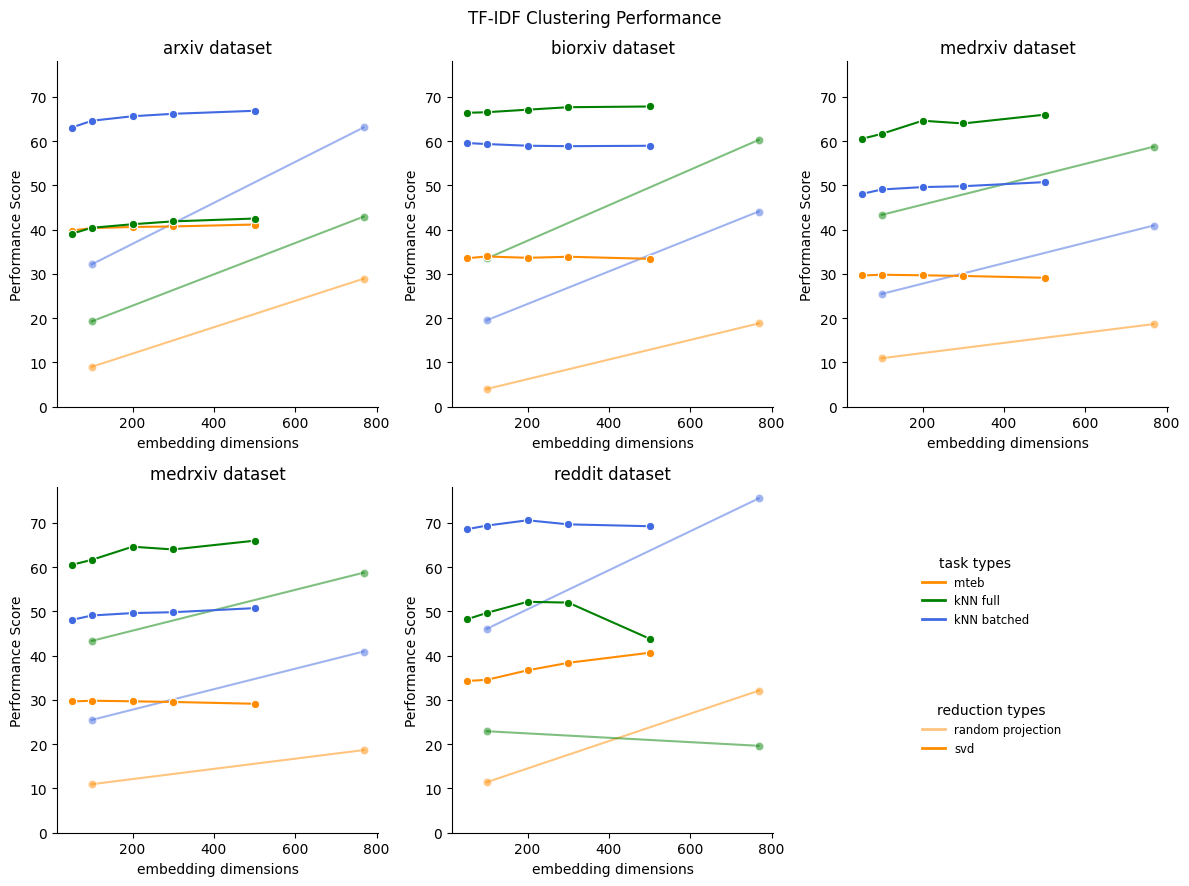

In [77]:
datasets = list(df_melted["dataset"].unique())

fix, axs = plt.subplots(2,3, figsize=(12,9))

# iterate through axes
for i in range(2):
    for j in range(3):
        ax = axs[i,j]
        if i==1 and j ==2:
            ax.axis("off")
        else:
            dataset = datasets[i*2+j]
        
            # each subplot shows 1 dataset
            df_dataset = df_melted[df_melted["dataset"] == dataset]

            # draw lineplots for each reduction type
            for red in reduction_types:
                df_subset = df_dataset[df_melted["reduction type"] == red]
                # one line for each task type
                for task in df_subset["task_types"].unique():
                    task_subset = df_subset[df_subset["task_types"] == task]
                    task_subset_sorted = task_subset.sort_values("embedding dimensions")
                    sns.lineplot(data=task_subset_sorted, x="embedding dimensions", y="score",
                                hue="task_types", palette=task_colors, alpha=opacity_dict[red],
                                ax=ax, markers=True, style="dataset")
        
            # design stuff
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.legend([], [], frameon=False)
            ax.set_ylabel("Performance Score")
            ax.set_ylim(0,78)
        
            ax.set_title(f"{dataset} dataset")


# Create a custom legend
# Legend for task types
task_legend = [
    Line2D([0], [0], color=color, lw=2, label=task)
    for task, color in task_colors.items()
]

# Legend for reduction types (using one example color)
example_color = list(task_colors.values())[0]
reduction_legend = [
    Line2D([0], [0], color=example_color, lw=2, alpha=opacity, label=red)
    for red, opacity in opacity_dict.items()
]

# Combine legends and add titles
legend_elements = task_legend + reduction_legend
legend_labels = ["Task Type"] * len(task_legend) + ["Reduction Type"] * len(reduction_legend)
legend_title = ["Task Type", "Reduction Type"]

# Place the legend in the empty subplot area
handles = task_legend #+ reduction_legend
labels = [line.get_label() for line in handles]
first_legend = axs[1, 2].legend(
    handles,
    labels,
    title="task types",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.2, 0.7),  
    title_fontsize='medium',
    fontsize='small',
)

#add legend manually to axes
axs[1, 2].add_artist(first_legend)

handles = reduction_legend
labels = [line.get_label() for line in handles]
axs[1, 2].legend(
    handles,
    labels,
    title="reduction types",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.2, 0.3),  
    title_fontsize='medium',
    fontsize='small',
)


plt.suptitle("TF-IDF Clustering Performance")
plt.tight_layout()
plt.show()

In [27]:
datasets

['arxiv', 'biorxiv', 'medrxiv', 'reddit', 'stackexchange']